# 1. Informasjon om filen

# 2. Innlasting av data

In [47]:
import sys
!{sys.executable} -m pip install scikit-learn

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [49]:
df_full = pd.read_csv("compas-scores-two-years.csv")
df_full = df_full[df_full["days_b_screening_arrest"] <= 30]
df_full = df_full[df_full["days_b_screening_arrest"] >= -30]

df_full.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1


In [50]:
df_full.info()

<class 'pandas.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       6172 non-null   int64  
 1   name                     6172 non-null   str    
 2   first                    6172 non-null   str    
 3   last                     6172 non-null   str    
 4   compas_screening_date    6172 non-null   str    
 5   sex                      6172 non-null   str    
 6   dob                      6172 non-null   str    
 7   age                      6172 non-null   int64  
 8   age_cat                  6172 non-null   str    
 9   race                     6172 non-null   str    
 10  juv_fel_count            6172 non-null   int64  
 11  decile_score             6172 non-null   int64  
 12  juv_misd_count           6172 non-null   int64  
 13  juv_other_count          6172 non-null   int64  
 14  priors_count             6172 non-null  

In [51]:
print(df_full.columns)

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')


In [52]:
print(df_full["race"].unique())

<StringArray>
[           'Other', 'African-American',        'Caucasian',
         'Hispanic',            'Asian',  'Native American']
Length: 6, dtype: str


Kolonner som ikke er nyttige: id, name, first, last, 
Kolonner som sannsynligvis ikke er nyttige: dob
Viktige kolonner: sex, age, age_cat, race

Ikke sett på alt...

# 3. Enkle analyser

### Hvor ofte ulike grupper gjentar forbrytelser

##### Kjønn

<Axes: xlabel='sex'>

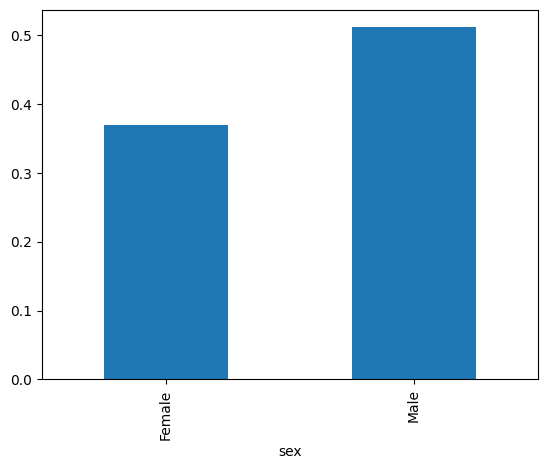

In [53]:

average_recidivism = df_full.groupby('sex')['is_recid'].mean()
average_recidivism.plot.bar()

##### Etnisitet

<Axes: xlabel='race'>

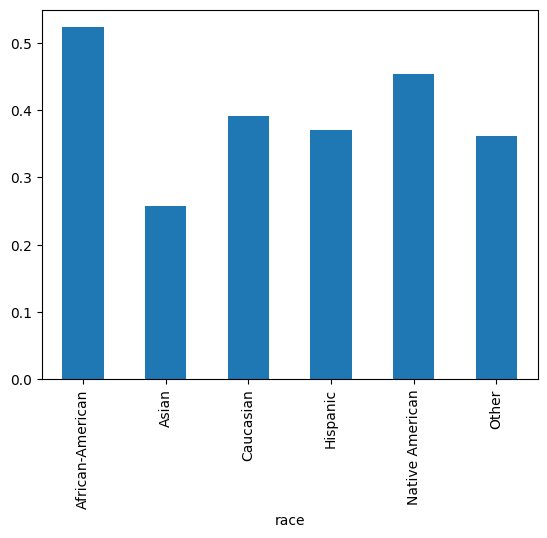

In [54]:
average_recidivism = df_full.groupby('race')['two_year_recid'].mean()
average_recidivism.plot.bar()

### Hvor ofte algoritmen predikerer tilbakefall (score 1-10 av risiko lav-høy)

##### Kjønn

<Axes: xlabel='sex'>

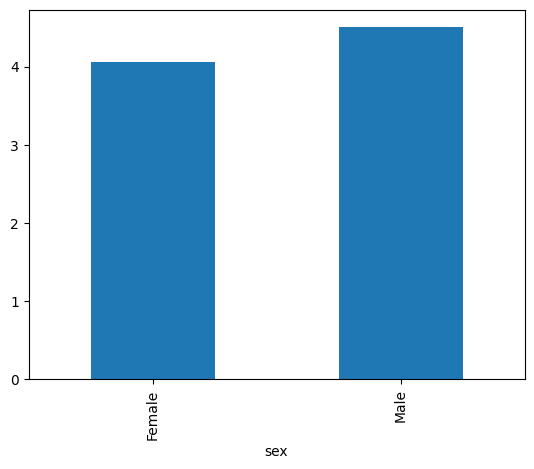

In [55]:
average_recidivism = df_full.groupby('sex')['decile_score'].mean()
average_recidivism.plot.bar()

##### Etnisitet

<Axes: xlabel='race'>

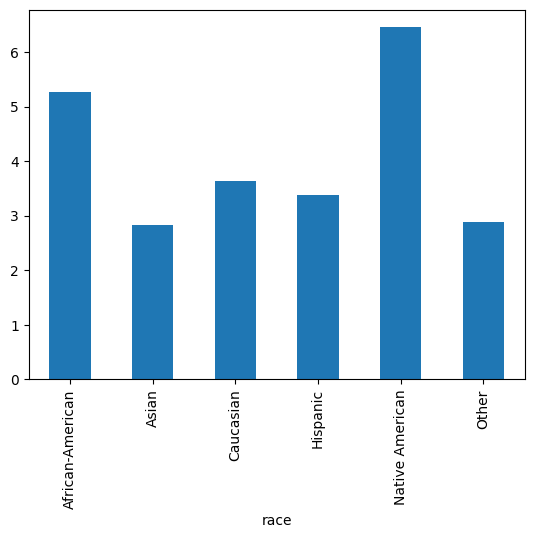

In [56]:
average_recidivism = df_full.groupby('race')['decile_score'].mean()
average_recidivism.plot.bar()

### Relativ frekvens av risikovurdering

##### Kjønn

<Axes: xlabel='sex,v_score_text'>

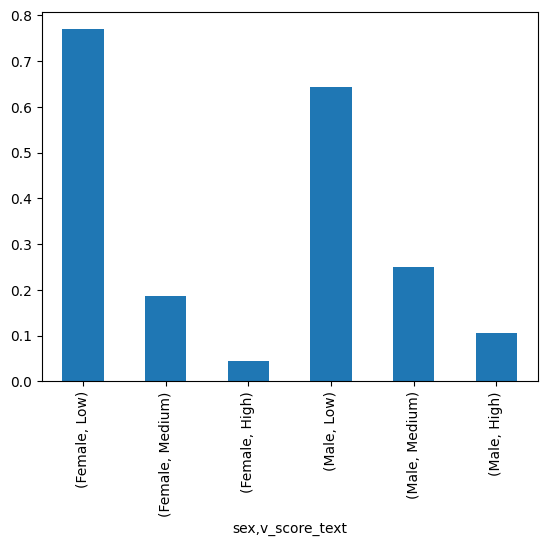

In [57]:
rel_freq = df_full.groupby('sex')['v_score_text'].value_counts(normalize=True)
rel_freq.plot.bar()

Etnisitet

<Axes: xlabel='race,v_score_text'>

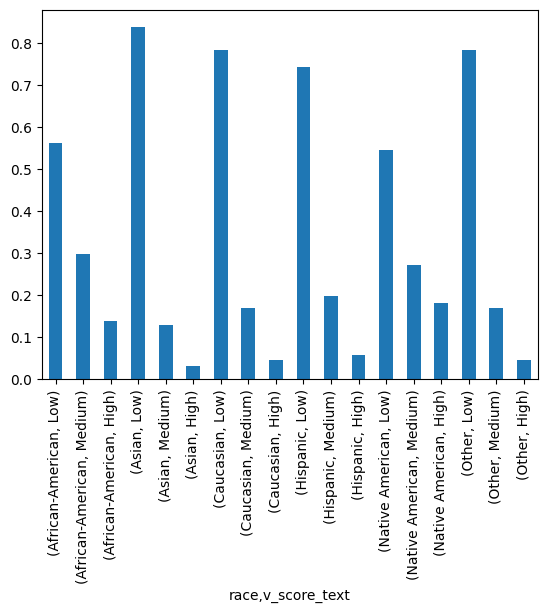

In [58]:
rel_freq = df_full.groupby('race')['v_score_text'].value_counts(normalize=True)
rel_freq.plot.bar()

### Confusion matrix // Treffsikkerhet positive og negative

Algoritmedataen sier ikke eksplisitt om den mener noen vil ha tilbakefall eller ikke. Det er tydeligvis vanlig å gruppere 1-4 / low som nei, og 5-10 / medium eller high som ja.

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

##### Totalt over alle grupper

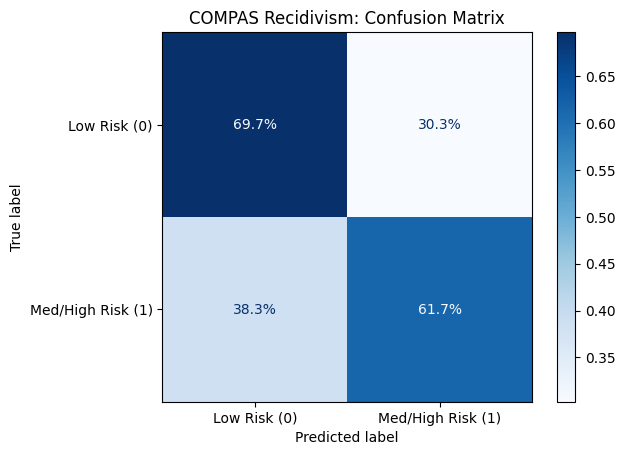

In [60]:
df_full['predicted_recid'] = df_full['score_text'].apply(lambda x: 1 if x in ['Medium', 'High'] else 0)
cm_rates = confusion_matrix(df_full['two_year_recid'], df_full['predicted_recid'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Blues', values_format='.1%')

plt.title('COMPAS Recidivism: Confusion Matrix')
plt.show()

### Filtrert etter grupper

##### Hvite

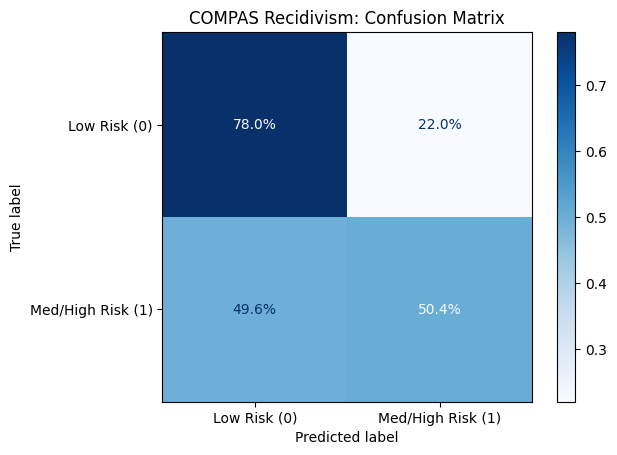

In [61]:
sortby = 'Caucasian'

df_full['predicted_recid'] = df_full['score_text'].apply(lambda x: 1 if x in ['Medium', 'High'] else 0)
df_sorted = df_full[df_full['race'] == sortby]


cm_rates = confusion_matrix(df_sorted['two_year_recid'], df_sorted['predicted_recid'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Blues', values_format='.1%')

plt.title('COMPAS Recidivism: Confusion Matrix')
plt.show()

##### Svarte

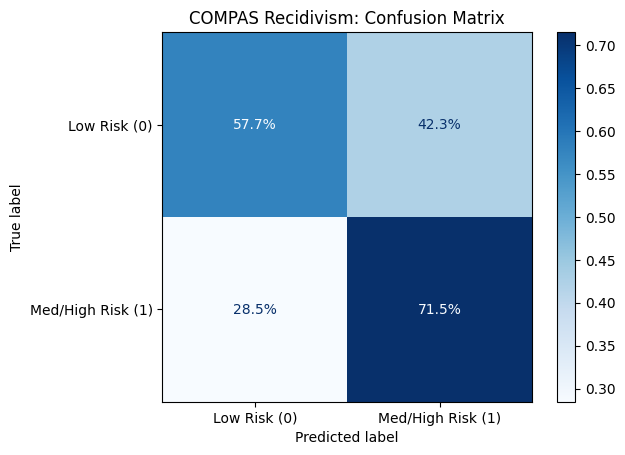

In [62]:
sortby = 'African-American'

df_full['predicted_recid'] = df_full['score_text'].apply(lambda x: 1 if x in ['Medium', 'High'] else 0)
df_sorted = df_full[df_full['race'] == sortby]


cm_rates = confusion_matrix(df_sorted['two_year_recid'], df_sorted['predicted_recid'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rates, 
                              display_labels=['Low Risk (0)', 'Med/High Risk (1)'])

disp.plot(cmap='Blues', values_format='.1%')

plt.title('COMPAS Recidivism: Confusion Matrix')
plt.show()